# 黑市九红最终概率

在学习了 黑马定律 后，终于回到了最开始的目标，九红到底有多难？

# 前人的探索：基于雷云火弹和中毒毒弹的九红@安静的躺指

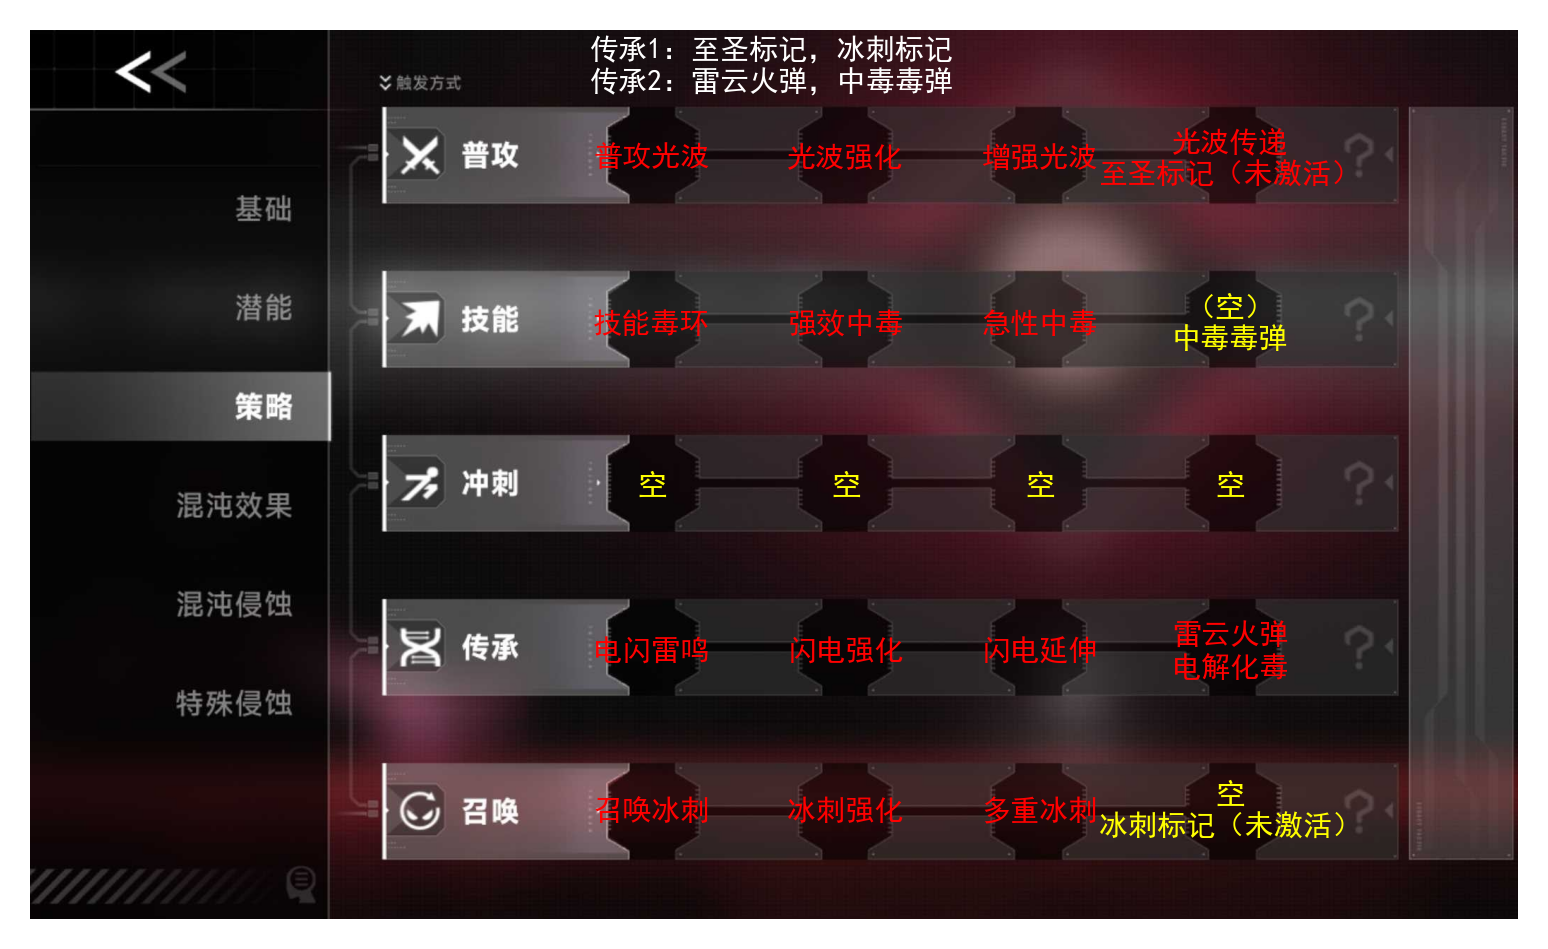

In [1]:
import utils

utils.draw_status("传承1：至圣标记，冰刺标记\n传承2：雷云火弹，中毒毒弹", [
    ["普攻光波", "光波强化", "增强光波", "光波传递\n至圣标记（未激活）"],
    ["技能毒环", "强效中毒", "急性中毒", "（空）\n中毒毒弹"],
    ["空", "空", "空", "空"],
    ["电闪雷鸣", "闪电强化", "闪电延伸", "雷云火弹\n电解化毒"],
    ["召唤冰刺", "冰刺强化", "多重冰刺", "空\n冰刺标记（未激活）"],
], font_size=7)

当前的黑市策略池：

- 技能位红策略：\[连续刃环\]
- 冲刺位基础策略：7个基础冲刺策略
- 召唤位红策略：\[无尽冰刺\]，\[冰刺再生\]

获得9红的路线原理：
1. 先获得召唤位红策略，执行2选1，**必须早于冲刺位**（因为\[冰刺标记\]的激活会占用位置，导致无法获得\[无尽冰刺\]和\[冰刺再生\]
2. 获得冲刺位的 \[圣光标记\]，解锁冲刺位的 一阶/二阶/单激活红，激活\[至圣标记\]和\[冰刺标记\]
3. 获得冲刺位的单激活红 \[标记闪光\]（无次序要求）
4. 获得技能位的单激活红 \[召唤刃环\]（无次序要求）
5. 获得任意一个其他策略

![](img/九红概率图1.png)

In [2]:
prob = 1 / 10 * 2 / 9 * 1 / 7 * 11 / 20
prob += 2 / 10 * 1 / 8 * 1 / 7 * 11 / 20
prob += 2 / 10 * 1 / 8 * 11 / 30
print(f"最终概率：{prob * 100:.2f}%")

最终概率：1.29%


# PS：本人也是通过这个方式拿到9红的，绝对是没有问题的
# PPS：该方案没有改进空间，如果留空一个二阶策略，会降低 \[冰刺红策略\] 和 \[冲刺红策略\] 和 \[技能位红策略\] 的概率，得不偿失。

# 前人的探索：基于冲刺三激活的九红 @OyO是Yenyo

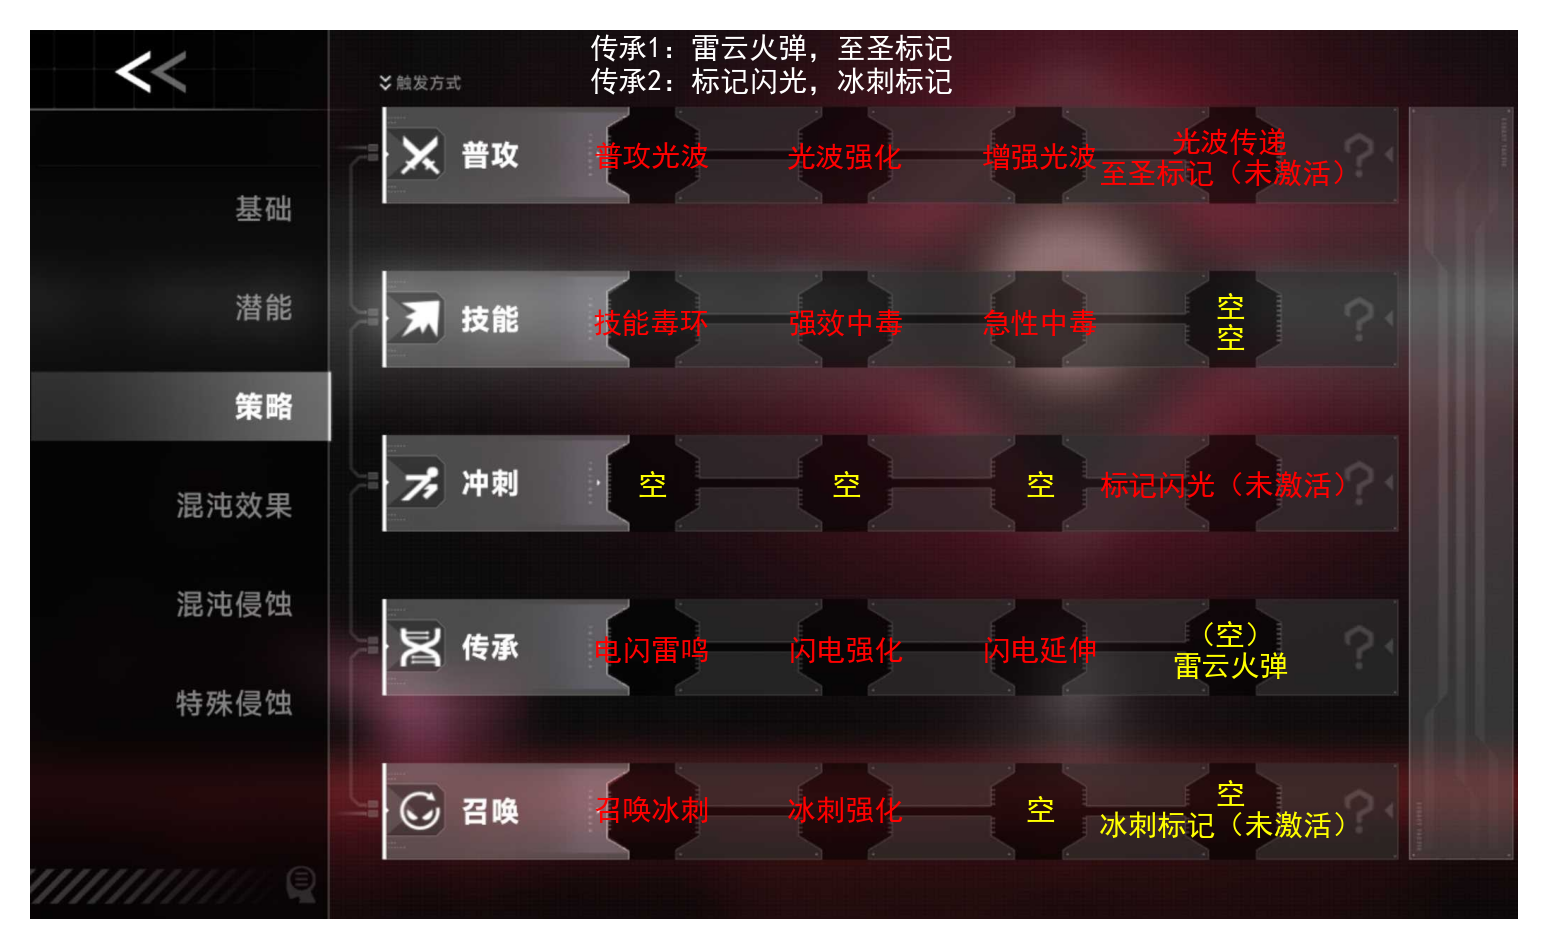

In [9]:
utils.draw_status("传承1：雷云火弹，至圣标记\n传承2：标记闪光，冰刺标记", [
    ["普攻光波", "光波强化", "增强光波", "光波传递\n至圣标记（未激活）"],
    ["技能毒环", "强效中毒", "急性中毒", "空\n空"],
    ["空", "空", "空", "标记闪光（未激活）"],
    ["电闪雷鸣", "闪电强化", "闪电延伸", "（空）\n雷云火弹"],
    ["召唤冰刺", "冰刺强化", "空", "空\n冰刺标记（未激活）"],
], font_size=7)

根据作者的思路，当前的策略池是：

- 技能位红策略：\[连续刃环\]，\[中毒毒弹\]
- 冲刺位基础策略：7个基础冲刺策略
- 传承位红策略：\[电解化毒\]
- 召唤位二阶强化：\[多重冰刺\]
- 召唤位红策略：\[无尽冰刺\]，\[冰刺再生\]

完成9红build时，随机获得的5个策略是:

- 2个技能位红策略
- 1个传承位红策略
- 1个召唤位红策略
- 任意一个冲刺位基础策略（后期可主动获得冲刺位的圣光标记）

作者提到，这里的 \[冰刺二阶强化\] 和 传承技红策略\[电解化毒\]也是故意留着的，而这两个策略是可以正常获得的。

可能是为了提高成功的概率？那么开始研究多种情况下，到底留空多少个位置的成功率是最高的

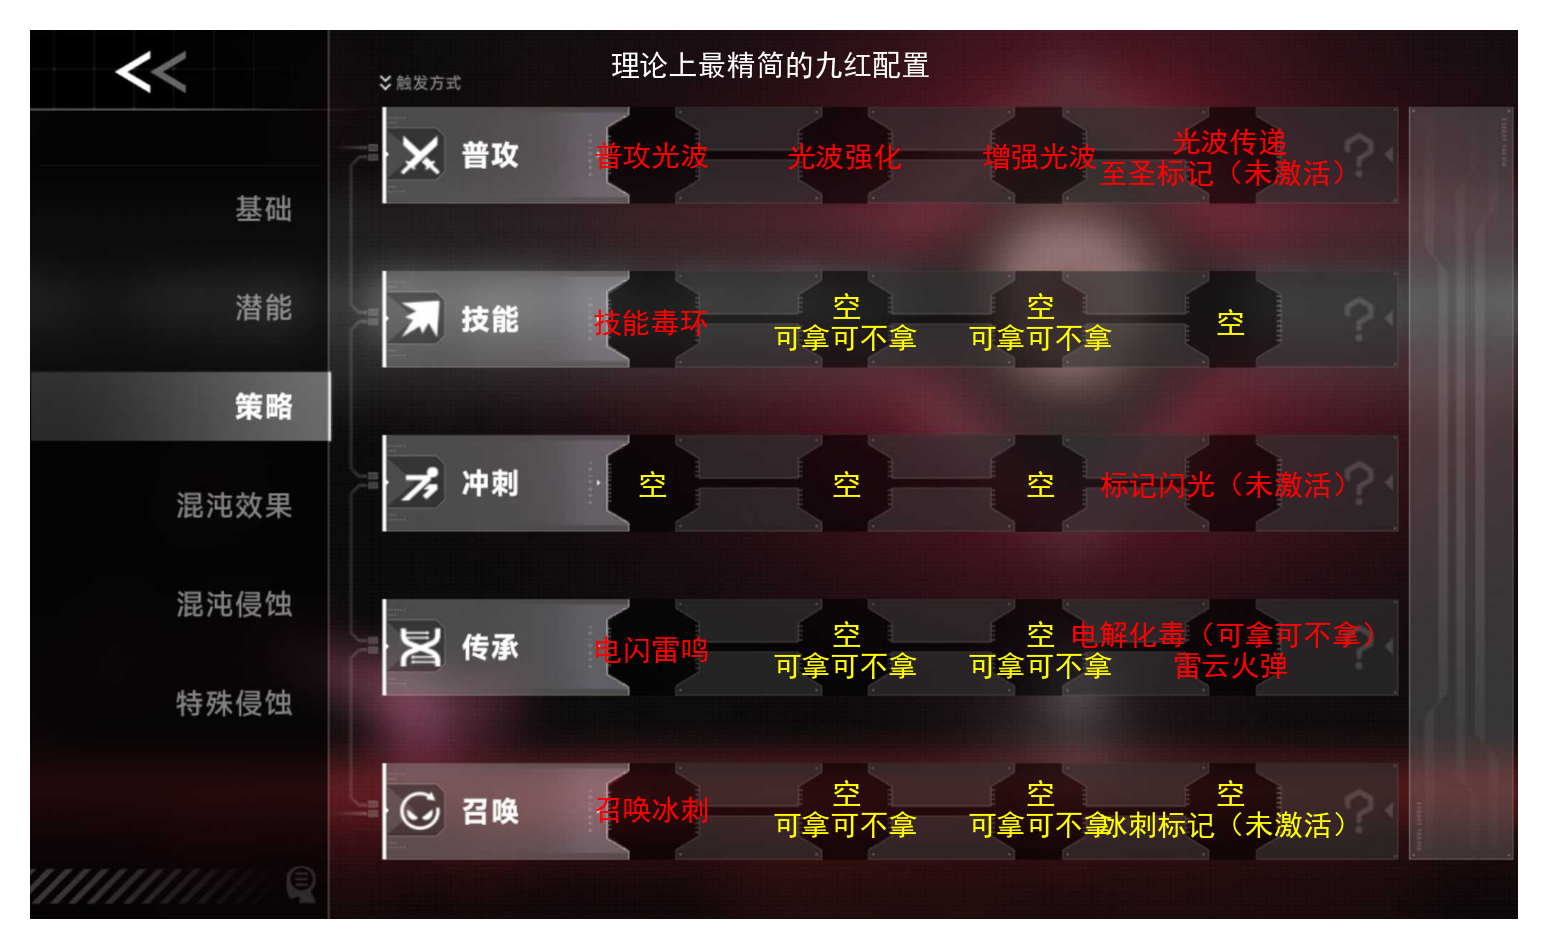

In [4]:
utils.draw_status("理论上最精简的九红配置", [
    ["普攻光波", "光波强化", "增强光波", "光波传递\n至圣标记（未激活）"],
    ["技能毒环", "空\n可拿可不拿", "空\n可拿可不拿", "空"],
    ["空", "空", "空", "标记闪光（未激活）"],
    ["电闪雷鸣", "空\n可拿可不拿", "空\n可拿可不拿", "电解化毒（可拿可不拿）\n雷云火弹"],
    ["召唤冰刺", "空\n可拿可不拿", "空\n可拿可不拿", "空\n冰刺标记（未激活）"],
], font_size=7)

在上图的极端情况下，理论上可以由黑市成功获得9红，顺序是：

\[中毒毒弹\] -> \[连续刃环\] -> \[电解化毒\] -> \[冰刺单激活红\] -> \[任意\]

当然，这个概率估计是 (1/25)的四次方，大约是 0.00000256，SL一辈子都不一定能出。

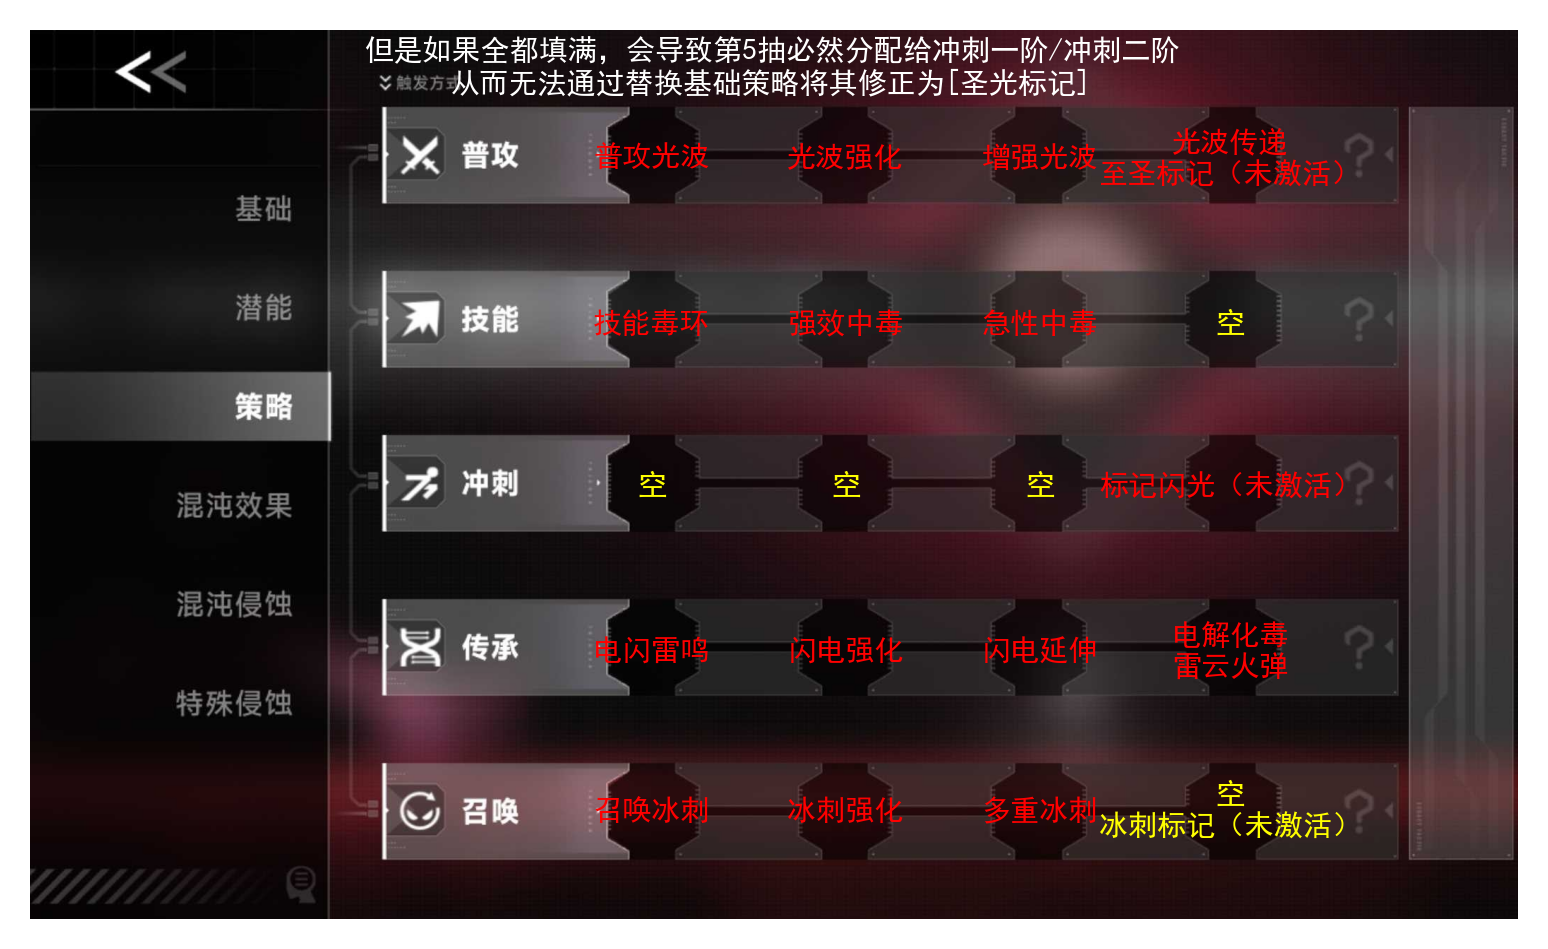

In [10]:
utils.draw_status("但是如果全都填满，会导致第5抽必然分配给冲刺一阶/冲刺二阶\n从而无法通过替换基础策略将其修正为[圣光标记]", [
    ["普攻光波", "光波强化", "增强光波", "光波传递\n至圣标记（未激活）"],
    ["技能毒环", "强效中毒", "急性中毒", "空"],
    ["空", "空", "空", "标记闪光（未激活）"],
    ["电闪雷鸣", "闪电强化", "闪电延伸", "电解化毒\n雷云火弹"],
    ["召唤冰刺", "冰刺强化", "多重冰刺", "空\n冰刺标记（未激活）"],
], font_size=7)

# 因此，比较如下几情况的九红概率

1. 全部填满，进入黑市
2. 留空1个，\[电解化毒\]（它和\[多重冰刺\]等价）
3. 留空2个，\[电解化毒\]和\[多重冰刺\]
4. 留空2个，\[多重冰刺\]和\[冰刺一阶强化（3个）\]
5. 留空3个，\[电解化毒\]和\[多重冰刺\]和\[冰刺一阶\]
6. 更多更多。。。我估计概率会更低，懒得测

# 但由于计算量实在太大，这里使用模拟执行的方式，执行100w次黑市，查看最终结果（顺便也验证基于中毒毒弹雷云火弹的计算概率 1.29% 是否正确）

运算过程见 heishi_simulator.py

# 运算结果让人眼前一亮，我果然找到了更先进的build！

| 构筑                                    | 模拟概率                          |
|---------------------------------------|-------------------------------|
| 基于雷云火弹和中毒毒弹                           | 1.28%                 |
| 基于冲刺三激活 case1                         | 1.47%                         |
| 基于冲刺三激活 case2                         | 3.45%                         |
| 基于冲刺三激活 case3                         | 3.79%                         |
| <font color='red'>基于冲刺三激活 case4</font> | <font color='red'>4.03%</font> |
| 基于冲刺三激活 case5                         | 3.30%                         |


# 最终推荐build！！！

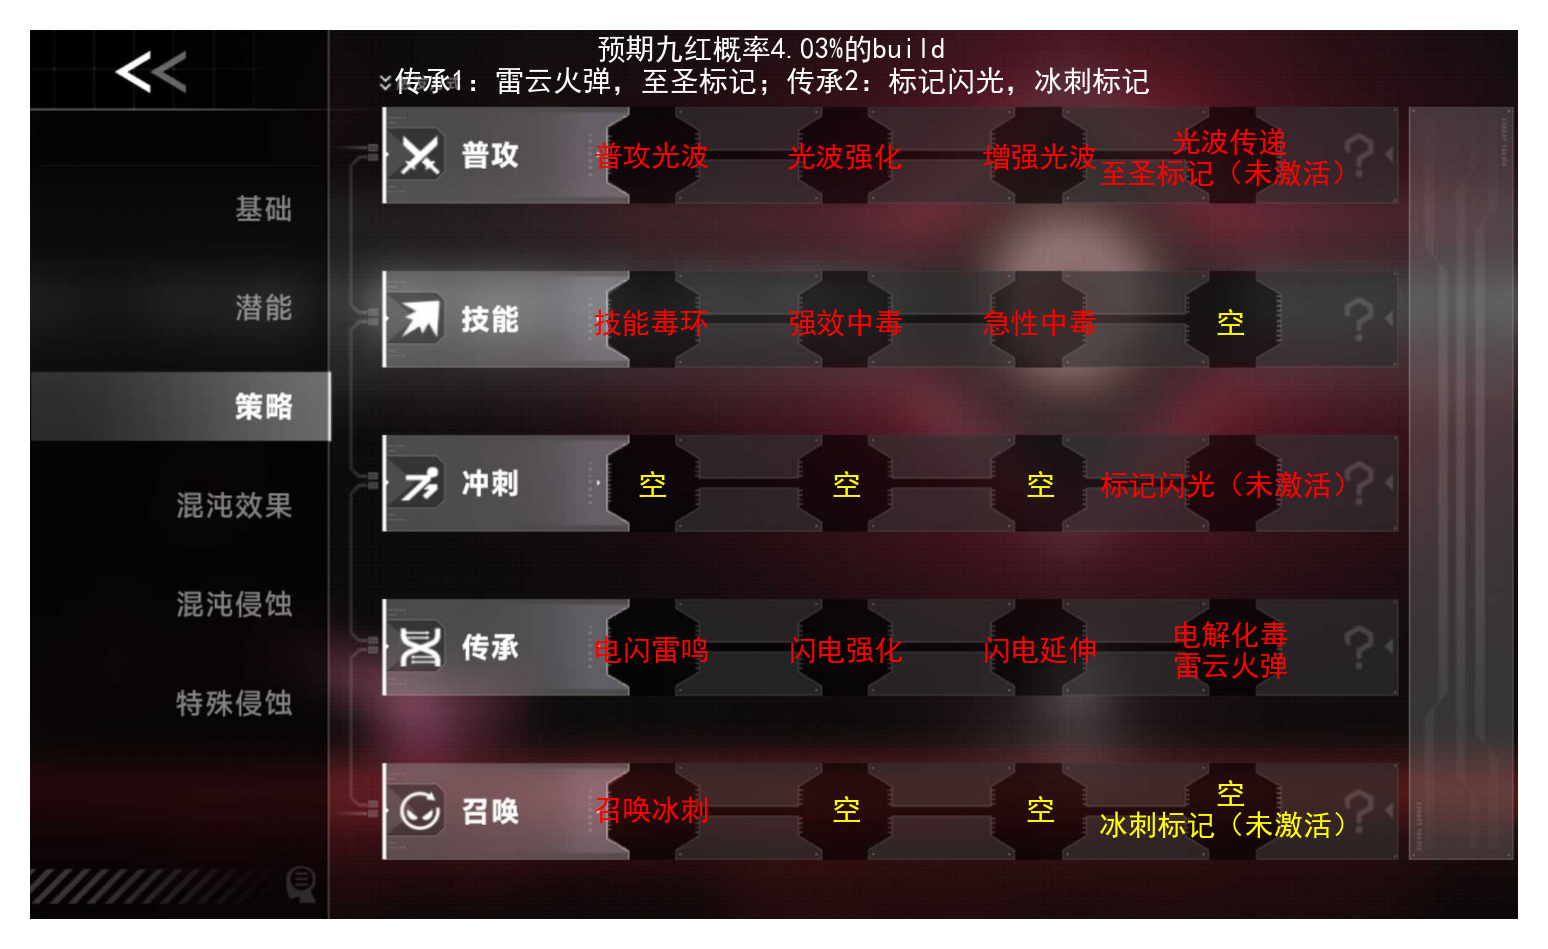

In [6]:
utils.draw_status("预期九红概率4.03%的build\n传承1：雷云火弹，至圣标记；传承2：标记闪光，冰刺标记", [
    ["普攻光波", "光波强化", "增强光波", "光波传递\n至圣标记（未激活）"],
    ["技能毒环", "强效中毒", "急性中毒", "空"],
    ["空", "空", "空", "标记闪光（未激活）"],
    ["电闪雷鸣", "闪电强化", "闪电延伸", "电解化毒\n雷云火弹"],
    ["召唤冰刺", "空", "空", "空\n冰刺标记（未激活）"],
], font_size=7)

# 题外话：为什么评论区总是有人无法得到九红？（全部都按照操作执行了）

## case1：纯运气不好

![](img/九红运气不好.png)
![](img/九红运气不好2.png)

## case2：被评论区误导，实际上是能出的
![](img/九红被评论区误导.png)
![](img/九红被评论区误导2.png)

# 最后的最后

感谢各位观众能看到这个地方，如果全程都看完，恭喜你完成了一次成功的科研经历，被迫跟着UP主学习了大学数学的概率论和数理统计。

本文投入了大量心血，最终实现了对前人方案的突破，完整地建立了：

- **苍翼四大定律**：均衡定律，替换定律，黑店定律，黑马定律
- **苍翼九红的最优解**：4.03%的超高概率

**希望各位看官们能奖励我 苍翼 应有的热度！！！！**

![](img/求三连.png)